# Netflix Data Analysis

### By Leesha

This project analyzes Netflix Movies and TV Shows dataset to uncover trends, content distribution, and key insights using Python.

##  Objective

The objective of this project is to analyze Netflix content and answer key questions such as:
- What type of content dominates Netflix (Movies vs TV Shows)?
- Which countries produce the most content?
- How has Netflix content grown over time?
- What are the most popular genres on Netflix?

In [ ]:
import pandas as pd

In [ ]:
import matplotlib.pyplot as plt

In [82]:
df=pd.read_csv('https://drive.google.com/uc?export=download&id=1r6DwJyOJxr6VKcdPXfwY4Ded8_jdnw8P')

##  Dataset Overview

The dataset contains information about Netflix Movies and TV Shows, including:
- Type (Movie/TV Show)
- Title
- Director and Cast
- Country of production
- Date added to Netflix
- Release year
- Genre (listed_in)

This dataset helps in understanding trends and patterns in Netflix content.

In [81]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

##  Data Cleaning

In this step, the dataset was prepared for analysis by:
- Filling missing values in columns like country, director, and cast
- Removing duplicate records
- Converting the 'date_added' column to datetime format
- Extracting the year from the date for trend analysis

This ensures that the dataset is clean and ready for accurate analysis.

In [58]:
# check missing values
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,3


In [93]:
# fill missing values
df['country'] = df['country'].fillna("Unknown")
df['director'] = df['director'].fillna("Unknown")
df['cast'] = df['cast'].fillna("Not Available")

# drop rows where critical data is missing
df = df.dropna(subset=['date_added', 'rating'])

# convert date column
df['date_added'] = pd.to_datetime(df['date_added'])

In [90]:
df['year_added'] = df['date_added'].dt.year

In [ ]:
df['type'].value_counts()

,count
type,
Movie,6129
TV Show,2664


In [ ]:
df['country'].value_counts().head(10)

,count
country,
United States,2812
India,972
Unknown,829
United Kingdom,418
Japan,243
South Korea,199
Canada,181
Spain,145
France,124


In [ ]:
df['year_added'].value_counts().sort_index()

,count
year_added,
2008,2
2009,2
2010,1
2011,13
2012,3
2013,11
2014,24
2015,82
2016,428


## What type of content dominates Netflix?

This analysis compares the distribution of Movies and TV Shows available on Netflix.

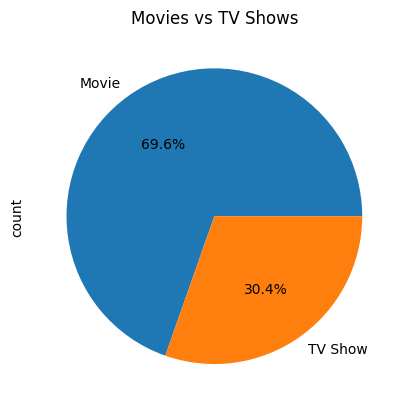

In [76]:
df['type'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Movies vs TV Shows")
plt.show()

 Insight:
Movies dominate the Netflix platform, making up a significantly larger portion of the content compared to TV Shows.

##  Which countries produce the most Netflix content?

This section analyzes the countries contributing the most content to Netflix.

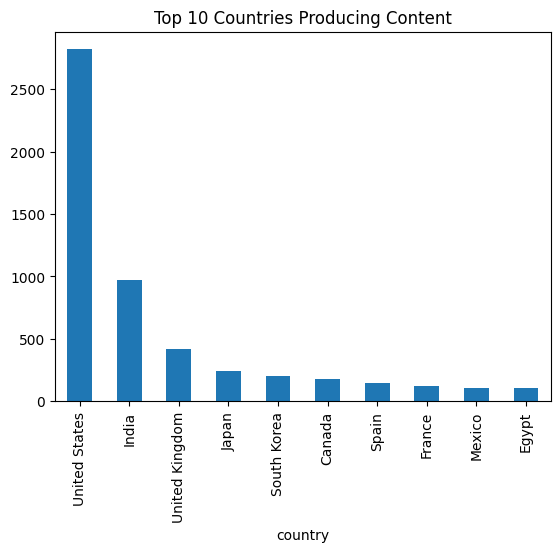

In [75]:
df['country'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Countries Producing Content")
plt.show()

Insight:
The United States is the leading contributor to Netflix content, followed by other countries like India and the United Kingdom.

##  How has Netflix content grown over the years?

This analysis shows the trend of content added to Netflix over time.

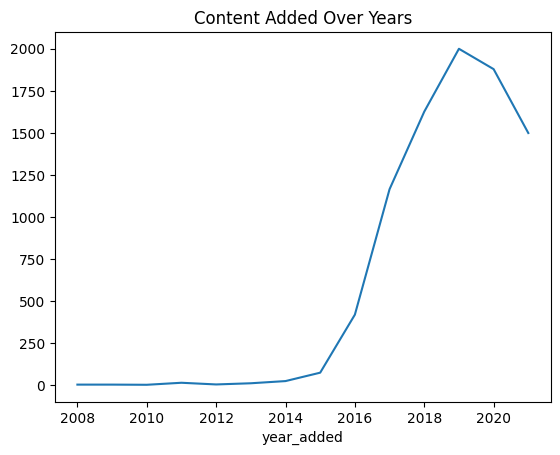

In [74]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year_added'] = df['date_added'].dt.year
df['year_added'].value_counts().sort_index().plot(kind='line')
plt.title("Content Added Over Years")
plt.show()

Insight:
There is a significant increase in content after 2015, showing Netflix’s rapid expansion in recent years.

##  What are the most popular genres on Netflix?

This section analyzes the most common genres available on Netflix.

In [69]:
# split genres and count them
genre_counts = df['listed_in'].str.split(',').explode().str.strip().value_counts()

# top 10 genres
top_genres = genre_counts.head(10)

top_genres

,count
listed_in,
International Movies,2752
Dramas,2427
Comedies,1674
International TV Shows,1351
Documentaries,869
Action & Adventure,859
TV Dramas,763
Independent Movies,756
Children & Family Movies,641


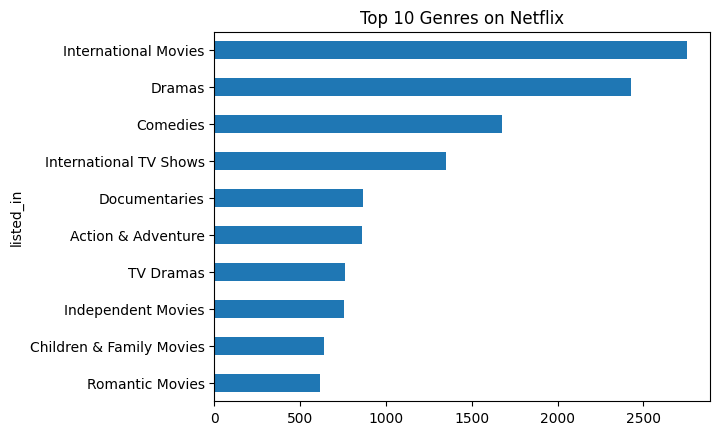

In [68]:
top_genres.sort_values().plot(kind='barh')
plt.title("Top 10 Genres on Netflix")
plt.show()

Insight:
Drama and Comedy are the most popular genres on Netflix, indicating a strong focus on widely consumed and engaging content.

##  Final Insights

- Movies dominate Netflix content over TV Shows  
- The United States produces the highest amount of content  
- Netflix content has grown rapidly, especially after 2015  
- Drama and Comedy are the most common genres  

These insights highlight Netflix’s content strategy and its focus on popular and scalable content categories.

##  Conclusion

This project provided a comprehensive analysis of Netflix content using Python.

The findings show that Netflix has significantly expanded its library over time, focusing on movies and popular genres. The platform relies heavily on content from major producing countries, especially the United States.

This type of analysis can be useful for understanding content trends, audience preferences, and business strategies in the entertainment industry.